<a href="https://colab.research.google.com/github/dsc-courses/cosmos-ml-cluster-2026/blob/main/lectures/lec13/lec13_mnist_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Build CNN for MNIST dataset

You can also refer to [this page](https://www.kaggle.com/code/prashant111/comprehensive-guide-to-cnn-with-keras) for more details.

In [ ]:
# load libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models, datasets

### Load MNIST dataset

In [ ]:
# Load the MNIST dataset using Keras built-in datasets
(X_train_tf, y_train_tf), (X_test_tf, y_test_tf) = tf.keras.datasets.mnist.load_data()

# Combine train and test data to form a single X and y, similar to fetch_openml output
X = np.concatenate((X_train_tf, X_test_tf), axis=0)
y = np.concatenate((y_train_tf, y_test_tf), axis=0)

# Flatten the images from 28x28 to 784 features, and convert y to int
X = X.reshape(X.shape[0], -1)
y = y.astype(int)

print(X.shape)
print(y.shape)

In [ ]:
# convert to np arrays so that we can use StandardScaler for scaling.
# we will need to reshape it again/
X = np.array(X)
y = np.array(y)

In [ ]:
X.shape

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Scale the data (important for neural networks)
# when working with images, it is common to scale the
# data by dividing everything by the max value (255)
# so that data is in [0, 1]
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Reshape `X_train` and `X-test` so it's compatible to CNN.

CNN Requires an array of input images, each of which is represented as a 2-D array (width x height) or a 3-D array (width x height x color depth)

In [ ]:
print (X_train.shape)
print (X_test.shape)

X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

print (X_train.shape)
print (X_test.shape)

### Construct a CNN

CNN consists of three layers: Convolutional, Pooling, and Fully-Connected (aka MLP).

In [ ]:
model = models.Sequential([

    layers.Conv2D(32, (5,5), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (5,5), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(10, activation='softmax')
])


model.summary()

### Explanation of the summary


*   The first convolutional layer: Applying a single 5x5 image filter to a 28x28x1 image would produce an output of 24x24x1 array. The first convolutional layer compiles 32 filters and each filter constructs a neuron at this convolutional layer. Thus, this convolutional layer includes ((5x5)x1 input to each neuron+1 for bias)x 32 neurons = 832 parameters to train.

*   The second convolutional layer: This layer uses 32 12x12 outputs from the first pooling layer, and compiles 64 5x5 image filters. Thus, there are ((5x5x32 inputs to each neuron)+1 for bias)x 64 neurons = 51254 parameters.


### Visual Representation of the CNN Structure





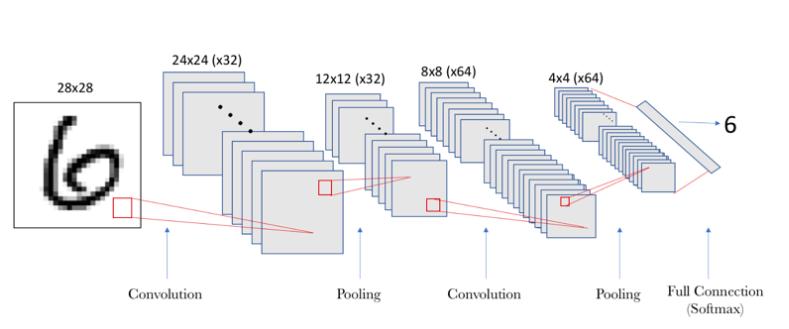

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train,
          batch_size= 100,
          epochs= 10)


### Quickly measure the goodness of the fit

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test accuracy:", acc)
print("Test loss:", loss)

In [ ]:
# Get the weights of the first convolutional layer
# model.layers[0] is the first Conv2D layer
filters, biases = model.layers[0].get_weights()

# Normalize filter values to be between 0 and 1 for visualization
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

# print the very first 5x5 filter as an example
print (filters[:, :, 0, 0])


In [ ]:
# Plot the 32 filters
n_filters = filters.shape[3] # Should be 32
rows = 4
cols = 8 # 4 * 8 = 32

plt.figure(figsize=(cols * 2, rows * 2))
for i in range(n_filters):
    # Get the i-th filter (it's 5x5x1, so take the 0th channel for grayscale)
    f = filters[:, :, 0, i]
    ax = plt.subplot(rows, cols, i + 1)
    ax.imshow(f, cmap='viridis') # 'gray' or 'viridis' or 'plasma' are good choices
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'Filter {i+1}')

plt.suptitle('Filters from the First Convolutional Layer', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

### Make the actual predictions using the test set


In [ ]:
# Generate predictions for the CNN model
y_pred_probabilities = model.predict(X_test)
y_pred = np.argmax(y_pred_probabilities, axis=1)

# Define the visualize_predictions function
def visualize_predictions(X, y_true, y_pred, title="Incorrect Predictions"):
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    fig.suptitle(title, fontsize=16)
    for i, ax in enumerate(axes.ravel()):
        if i < len(X):
            # Reshape X for imshow, handling the channel dimension (28, 28, 1) -> (28, 28)
            image = X[i].reshape(28, 28)
            ax.imshow(image, cmap='gray')
            ax.set_title(f"True: {y_true[i]}\nPred: {y_pred[i]}")
            ax.axis('off')
        else:
            ax.axis('off') # Hide empty subplots if there are fewer than 10 incorrect predictions
    plt.show()

# Find incorrectly predicted images
incorrect_indices = np.where(y_test != y_pred)[0]
X_incorrect = X_test[incorrect_indices]
y_true_incorrect = y_test[incorrect_indices]
y_pred_incorrect = y_pred[incorrect_indices]

# Visualize the incorrectly predicted images
visualize_predictions(X_incorrect, y_true_incorrect, y_pred_incorrect, title="Incorrect Predictions by CNN Model")